Outlier Detection and Removal using percentile

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv('weight-height.csv')
df.sample(5)

,Gender,Height,Weight
968,Male,64.922336,179.409092
4817,Male,67.652786,165.103770
6709,Female,68.991691,183.638580
4933,Male,69.613404,188.868778
1037,Male,69.084897,189.856786


In [13]:
df.shape

(10000, 3)

In [4]:
df['Height'].describe()

,Height
count,10000.000000
mean,66.367560
std,3.847528
min,54.263133
25%,63.505620
50%,66.318070
75%,69.174262
max,78.998742


/tmp/ipykernel_6141/2441051004.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['Height'])


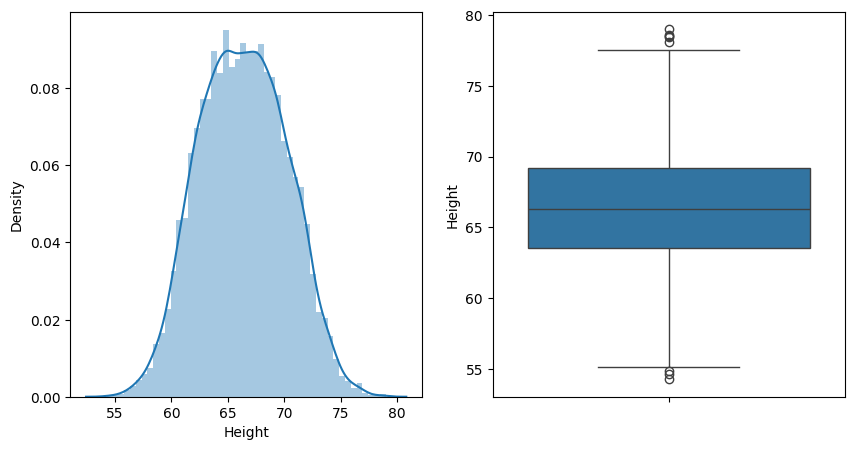

In [8]:
plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
sns.distplot(df['Height'])
plt.subplot(1,2,2)
sns.boxplot(df['Height'])
plt.show()

Find limit and detect outliers

In [9]:
upper = df['Height'].quantile(0.99)
lower = df['Height'].quantile(0.01)
upper,lower

(np.float64(74.7857900583366), np.float64(58.13441158671655))

In [10]:
outliers = df[(df['Height'] > upper) | (df['Height'] < lower)]
outliers.sample(5)

,Gender,Height,Weight
2971,Male,75.156879,250.317151
7361,Female,57.112539,98.794038
4044,Male,74.793288,215.235440
215,Male,74.795375,232.635403
7586,Female,56.737183,91.605437


In [11]:
outliers.shape

(200, 3)

Trimming

In [14]:
new_df = df[(df['Height']<upper) & (df['Height']>lower)]
new_df.sample(5)

,Gender,Height,Weight
1251,Male,64.577312,150.183474
1463,Male,64.729616,161.952431
9083,Female,59.321533,102.042028
6719,Female,65.935525,135.926725
5742,Female,63.916597,145.624291


In [15]:
new_df.shape

(9800, 3)

In [17]:
new_df['Height'].describe()

,Height
count,9800.000000
mean,66.364366
std,3.645075
min,58.134496
25%,63.577162
50%,66.318070
75%,69.119896
max,74.785714


/tmp/ipykernel_6141/4071629104.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(new_df['Height'])


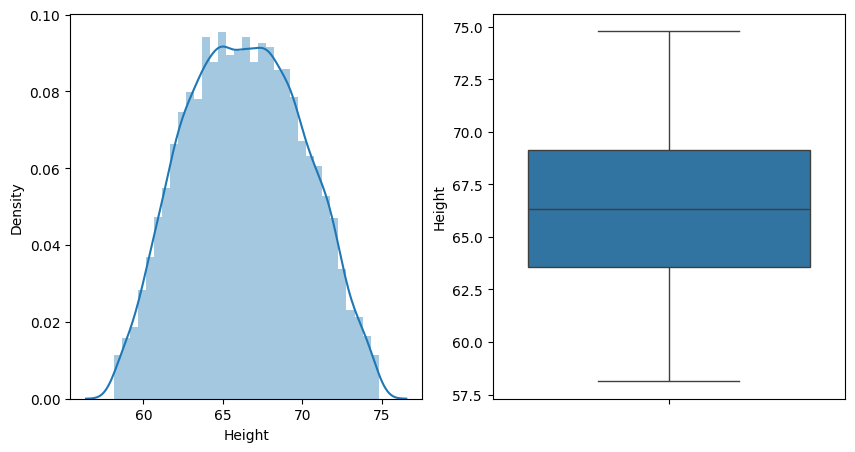

In [18]:
plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
sns.distplot(new_df['Height'])
plt.subplot(1,2,2)
sns.boxplot(new_df['Height'])
plt.show()

Capping

In [19]:
df['Height'] = np.where(
    df['Height']>upper,
    upper,
    np.where(
        df['Height']<lower,
        lower,
        df['Height']
    )
)
df['Height'].describe()

,Height
count,10000.000000
mean,66.366281
std,3.795717
min,58.134412
25%,63.505620
50%,66.318070
75%,69.174262
max,74.785790


/tmp/ipykernel_6141/2441051004.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['Height'])


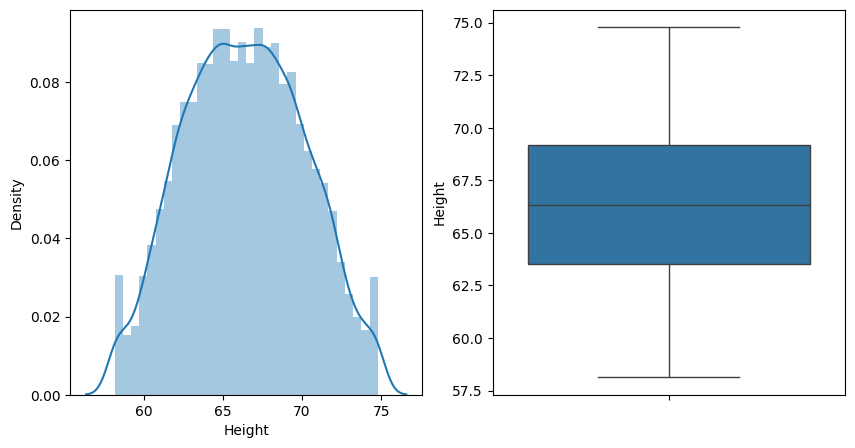

In [20]:
plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
sns.distplot(df['Height'])
plt.subplot(1,2,2)
sns.boxplot(df['Height'])
plt.show()